## Karat clustering

In this notebook we cluster the IF segments extracted from seismic data obtained from the KARAT station in a Greenland seismometer network. 

The notebook contains the following:
1. Clustering of the IF segments.
2. Analysis of the clusters.
3. Dendrogram illustrating the clusters

In [ ]:
# imports
import pickle
import obspy

import pandas as pd
import numpy as np

from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    extract_split_flows,
    find_date_in_strings,
)


from joblib import load
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform, pdist
from dynamicTreeCut import cutreeHybrid
from seismicif.metrics import iou
from seismicif.datamod.loading_utils import read_segment, sliding_windows_from_trace
from seismicif.datamod.trigger_utils import trace_trigger_detections
from seismicif.isolation_forest.utils import create_if_stream

Below we load:

1. The KARAT catalog
2. IF segments.
3. Segment DTW distances of the IF segments w.r.t. the reference segments.
4. Extract labels from the catalog.

In [31]:
# define paths
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)
control_paths = find_paths("DK", "KARAT_CONT", "HHZ.D", start=2022, stop=2023)

# load catalog, IF segments and IF model
catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)
if_mod = load(f"../output/{network}/if/models/{station}.joblib")

# load DTW results
dtw_path = f"../output/{network}/dtw/distances/{station}.pkl"

with open(f"{dtw_path}", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

# extract labels
labs = np.array([""] * len(segments), dtype=object)
remark = np.array([""] * len(segments), dtype=object)

start_catalog = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
        start_catalog.append(catalog.iloc[np.where(np.append(I[0], np.diff(I)) > 0)[0]])
        remark[i] = catalog["remarks"][
            np.where(np.append(I[0], np.diff(I)) > 0)[0]
        ].values[0]
    except IndexError:
        labs[i] = None

Next we add the IF segment score, control IF segment score and length of the region of interest as additional features to the segment DTW distances.

All the features are then normalized to have a minimum and maximum of 0 and 1 respectively (min-max normalization).

In [22]:
# extract features and normalize
Xa = X.copy()
lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = lens.reshape(-1, 1)
Xa = np.hstack([Xa, lens])
Xa = np.hstack([Xa, segments[["scores", "control_scores"]].values])

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Below we perform ward linkage of the extracted features and use the Dynamic Hybrid cut method to determine the clusters.

In [41]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
print("number of clusters:", len(set(clusters)))

..cutHeight not given, setting it to 20.76284980709905  ===>  99% of the (truncated) height range in dendro.
..done.
number of clusters: 13


## Analysis of clusters

### Cluster 13

Exclusively populated by highly ranked IF segments flagged before 2022-08-15 when the instrument was streaming sporadically and with high amplitudes. 

In [44]:
segments[clusters == 13]

,start,stop,most_anomalous_start,scores,control_scores,cluster,label,remarks
0,2022-05-30T13:35:29.900000Z,2022-05-30T13:39:39.900000Z,2022-05-30T13:35:29.900000Z,0.747250,0.366479,13,N,instrument
2,2022-05-31T07:01:09.385000Z,2022-05-31T07:06:09.385000Z,2022-05-31T07:02:49.385000Z,0.742488,0.568778,13,N,instrument
3,2022-06-14T00:00:00.000000Z,2022-06-14T14:47:30.000000Z,2022-06-14T10:18:20.000000Z,0.742142,0.536593,13,N,instrument
4,2022-06-12T00:00:00.000000Z,2022-06-13T11:07:30.000000Z,2022-06-13T09:45:50.000000Z,0.739093,0.564561,13,N,instrument
5,2022-06-13T11:11:46.565000Z,2022-06-13T14:13:26.565000Z,2022-06-13T13:26:46.565000Z,0.738705,0.499004,13,N,instrument
6,2022-06-13T15:41:05.655000Z,2022-06-13T23:59:25.655000Z,2022-06-13T15:41:05.655000Z,0.738353,0.460225,13,N,instrument
7,2022-06-13T14:17:52.775000Z,2022-06-13T15:36:12.775000Z,2022-06-13T14:52:52.775000Z,0.737334,0.472147,13,N,instrument
8,2022-06-15T00:00:00.000000Z,2022-06-16T07:31:40.000000Z,2022-06-15T11:20:50.000000Z,0.736619,0.478394,13,N,instrument
9,2022-06-11T13:51:33.165000Z,2022-06-11T23:59:53.165000Z,2022-06-11T14:23:13.165000Z,0.731432,0.508243,13,N,instrument
10,2022-06-16T08:50:49.545000Z,2022-06-16T09:45:49.545000Z,2022-06-16T09:09:59.545000Z,0.726878,0.400354,13,N,instrument


### Cluster 11

The noise class was expanded to include IF segments corresponding to anthropogenic events such as installation and service work near the station, helicopters arriving and departing from the station alongside electronic glitches/spikes. 
The majority of the IF segments in cluster 11 correspond to these events, with one IF segment possibly related to a mass movement, but with a degree of uncertainty.

In [82]:
segments[clusters == 11]

,start,stop,most_anomalous_start,scores,control_scores,cluster,label,remarks
21,2023-07-18T17:24:52.320000Z,2023-07-18T17:31:32.320000Z,2023-07-18T17:28:12.320000Z,0.707347,0.366802,11,N,helicopter
29,2023-07-18T16:54:52.320000Z,2023-07-18T17:03:12.320000Z,2023-07-18T16:58:12.320000Z,0.699165,0.377177,11,N,helicopter
65,2022-08-16T15:59:10.000000Z,2022-08-16T16:01:40.000000Z,2022-08-16T15:59:10.000000Z,0.659184,0.399606,11,N,helicopter or anthropogenic
66,2022-09-04T11:58:39.410000Z,2022-09-04T12:01:09.410000Z,2022-09-04T11:58:39.410000Z,0.659022,0.424882,11,N,glitch
71,2023-07-27T14:43:20.000000Z,2023-07-27T14:45:50.000000Z,2023-07-27T14:43:20.000000Z,0.657562,0.392039,11,N,glitch
83,2022-09-14T11:27:07.355000Z,2022-09-14T11:32:07.355000Z,2022-09-14T11:27:07.355000Z,0.652891,0.490002,11,CAL,uncertain
85,2022-08-16T13:09:10.000000Z,2022-08-16T13:11:40.000000Z,2022-08-16T13:10:00.000000Z,0.651946,0.404835,11,N,glitch
132,2022-09-04T13:39:50.385000Z,2022-09-04T13:42:20.385000Z,2022-09-04T13:39:50.385000Z,0.637212,0.431290,11,N,low freq electronic spike
161,2022-08-16T15:51:40.000000Z,2022-08-16T15:53:20.000000Z,2022-08-16T15:51:40.000000Z,0.631348,0.402730,11,N,low freq electronic spike
165,2022-08-15T18:17:53.515000Z,2022-08-15T18:19:33.515000Z,2022-08-15T18:17:53.515000Z,0.630665,0.425024,11,N,instrument


### Cluster 1

In what follows below we introduce the concept if high-pass screening:

Extract the raw waveform over the IF segment and reprocess it by increasing the corner frequency of the zero-phase high-pass filter to 0.5 Hz and reapplying
the IF trigger with no retraining. IF no segment remains then the IF segment is "high-pass screened".

1. 29.91% of the members come from 2022-09-25 or 2022-09-26.
2. these days contain a significant number of gaps in the corresponding recordings, so that spectrograms could not be computed. 
3. no IF segments survivied the high-pass screening -> we did not explore this cluster further. 


In [ ]:
cluster_segments = segments[segments["cluster"] == 1].reset_index(drop=True)

In [141]:
num = np.sum(["2022-09-25" in i for i in cluster_segments["start"]]) + np.sum(
    ["2022-09-26" in i for i in cluster_segments["start"]]
)
print(
    "Percentage of segments in cluster 1 in 2022-09-25 or 2022-09-26:",
    np.round(100 * num / len(cluster_segments), 2),
)

st = obspy.read(find_date_in_strings(karat_paths, "2022-09-25")[0])
print("Number of gaps in 2022-09-25:", len(st) - 1)

st = obspy.read(find_date_in_strings(karat_paths, "2022-09-26")[0])
print("Number of gaps in 2022-09-26:", len(st) - 1)

Percentage of segments in cluster 1 in 2022-09-25 or 2022-09-26: 29.91
Number of gaps in 2022-09-25: 198
Number of gaps in 2022-09-26: 192


In [142]:
# note the number of warnings
screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.

Number of screened survivors: 0


### Cluster  4

1. 95.16% of the members come from 2022-09-25.
2. one survivor from the high-pass screening process corresponding to noise -> since no mass-movement in the survivor we do not explore this cluster further.

In [143]:
cluster_segments = segments[segments["cluster"] == 4].reset_index(drop=True)

In [144]:
num = np.sum(["2022-09-25" in i for i in cluster_segments["start"]])
print(
    "Percentage of segments in cluster 4 in 2022-09-25:",
    np.round(100 * num / len(cluster_segments), 2),
)

Percentage of segments in cluster 4 in 2022-09-25: 95.16


In [145]:
screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.

Number of screened survivors: 1


In [146]:
screened_survivors

[start                   2022-12-25T03:15:00.000000Z
 stop                    2022-12-25T03:21:40.000000Z
 most_anomalous_start    2022-12-25T03:16:40.000000Z
 scores                                     0.644612
 control_scores                             0.499762
 cluster                                           4
 label                                             N
 remarks                                         NaN
 Name: 3, dtype: object]

### Clusters 2, 3, 5, 7, 10 

1. Cluster 2: No segments survived the high-pass screening.
2. Cluster 3: Two segments survived the high-pass screening, but none of the two corresponds to a mass movement.
3. Cluster 5: No segments survived the high-pass screening.
4. Cluster 7: No segments survived the high-pass screening.

Consequentially none of these clusters were further explored.

In [ ]:
# cluster 2
cluster_segments = segments[segments["cluster"] == 2].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 0


In [ ]:
# cluster 3
cluster_segments = segments[segments["cluster"] == 3].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 2


In [152]:
screened_survivors

[start                   2022-12-14T18:12:30.000000Z
 stop                    2022-12-14T19:07:30.000000Z
 most_anomalous_start    2022-12-14T18:49:10.000000Z
 scores                                     0.651277
 control_scores                             0.598406
 cluster                                           3
 label                                           TEQ
 remarks                                 M6.3 Alaska
 Name: 0, dtype: object,
 start                   2022-09-09T04:24:10.350000Z
 stop                    2022-09-09T05:22:30.350000Z
 most_anomalous_start    2022-09-09T04:57:30.350000Z
 scores                                     0.638748
 control_scores                             0.495389
 cluster                                           3
 label                                             N
 remarks                                         NaN
 Name: 2, dtype: object]

In [ ]:
# cluster 5
cluster_segments = segments[segments["cluster"] == 5].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 0


In [154]:
# cluster 7
cluster_segments = segments[segments["cluster"] == 7].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 0


### Cluster 6

1. 12 segments survived the high-pass screening which included a calving event.
2. Consequentially, the entirety of the cluster was explored.
3. Majority of the cluster corresponds to earthquakes.

In [156]:
# cluster 6
cluster_segments = segments[segments["cluster"] == 6].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)


Number of screened survivors: 12


In [159]:
screened_survivors[0]

start                   2023-07-27T06:56:40.000000Z
stop                    2023-07-27T07:06:40.000000Z
most_anomalous_start    2023-07-27T07:00:00.000000Z
scores                                     0.720379
control_scores                             0.703281
cluster                                           6
label                                           CAL
remarks                 Potential Big Calving Event
Name: 0, dtype: object

In [166]:
values, counts = np.unique(cluster_segments["label"].values, return_counts=True)
df = pd.DataFrame({"label": values, "membership": counts / counts.sum() * 100})

print(df)

  label  membership
0   CAL    5.769231
1     N    7.692308
2   REQ   17.307692
3   TEQ   69.230769


### Cluster 8

1. 37 segments survived the high-pass screening which included calving events.
2. Consequentially, the entirety of the cluster was explored.
3. 86.36% of the cluster corresponds to mass movements.

In [ ]:
cluster_segments = segments[segments["cluster"] == 8].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 37


In [171]:
screened_survivors[1]

start                                       2023-08-25T12:39:10.000000Z
stop                                        2023-08-25T12:47:30.000000Z
most_anomalous_start                        2023-08-25T12:41:40.000000Z
scores                                                         0.720424
control_scores                                                 0.462266
cluster                                                               8
label                                                               CAL
remarks                 verified by Satellite images on 22-08 and 28-08
Name: 1, dtype: object

In [169]:
values, counts = np.unique(cluster_segments["label"].values, return_counts=True)
df = pd.DataFrame({"label": values, "membership": counts / counts.sum() * 100})

print(df)

  label  membership
0   CAL   86.363636
1     N   13.636364


### Cluster 9

1. 11 segments survived the high-pass screening procedure all corresponding to mass movements.
2. the cluster represents a pure mass movement cluster.

In [ ]:
cluster_segments = segments[segments["cluster"] == 9].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 11


In [173]:
values, counts = np.unique(cluster_segments["label"].values, return_counts=True)
df = pd.DataFrame({"label": values, "membership": counts / counts.sum() * 100})

print(df)

  label  membership
0   CAL       100.0


### Cluster 10

1. 11 IF segments survived the high-pass screening including a segments corresponding to the Dixon fjord rock avalanche and tsunami.
2. Of these remaining segments 63.64% corresponds to mass movements.

In [178]:
cluster_segments = segments[segments["cluster"] == 10].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 11


In [182]:
screened_survivors[3]

start                   2023-09-16T12:27:39.390000Z
stop                    2023-09-16T12:49:19.390000Z
most_anomalous_start    2023-09-16T12:29:19.390000Z
scores                                     0.698963
control_scores                             0.602158
cluster                                          10
label                                           CAL
remarks                         dixon fjord tsunami
Name: 3, dtype: object

In [184]:
values, counts = np.unique(
    pd.DataFrame(screened_survivors)["label"].values, return_counts=True
)
df = pd.DataFrame({"label": values, "membership": counts / counts.sum() * 100})

print(df)

  label  membership
0   CAL   63.636364
1     N   18.181818
2   REQ    9.090909
3   TEQ    9.090909


### Cluster 12

All the IF segments survived the high-pass screening and all corresponded to mass movements. The ID here stands for iceberg disintegration.

In [175]:
cluster_segments = segments[segments["cluster"] == 12].reset_index(drop=True)

screened_survivors = []
for i in range(len(cluster_segments)):
    seg = read_segment(
        cluster_segments.iloc[i]["start"],
        cluster_segments.iloc[i]["stop"],
        karat_paths,
        filter_freq=0.5,
    )
    X, T = sliding_windows_from_trace(seg)
    T = np.array(T)
    if_scores = -if_mod.score_samples(X)
    if any(if_scores >= 0.60):
        screened_survivors.append(cluster_segments.iloc[i])

print("Number of screened survivors:", len(screened_survivors))

Number of screened survivors: 20


In [177]:
values, counts = np.unique(cluster_segments["label"].values, return_counts=True)
df = pd.DataFrame({"label": values, "membership": counts / counts.sum() * 100})

print(df)

  label  membership
0   CAL        95.0
1    ID         5.0


## Dendrogram

Below is a dendrogram illustrating the clustering.

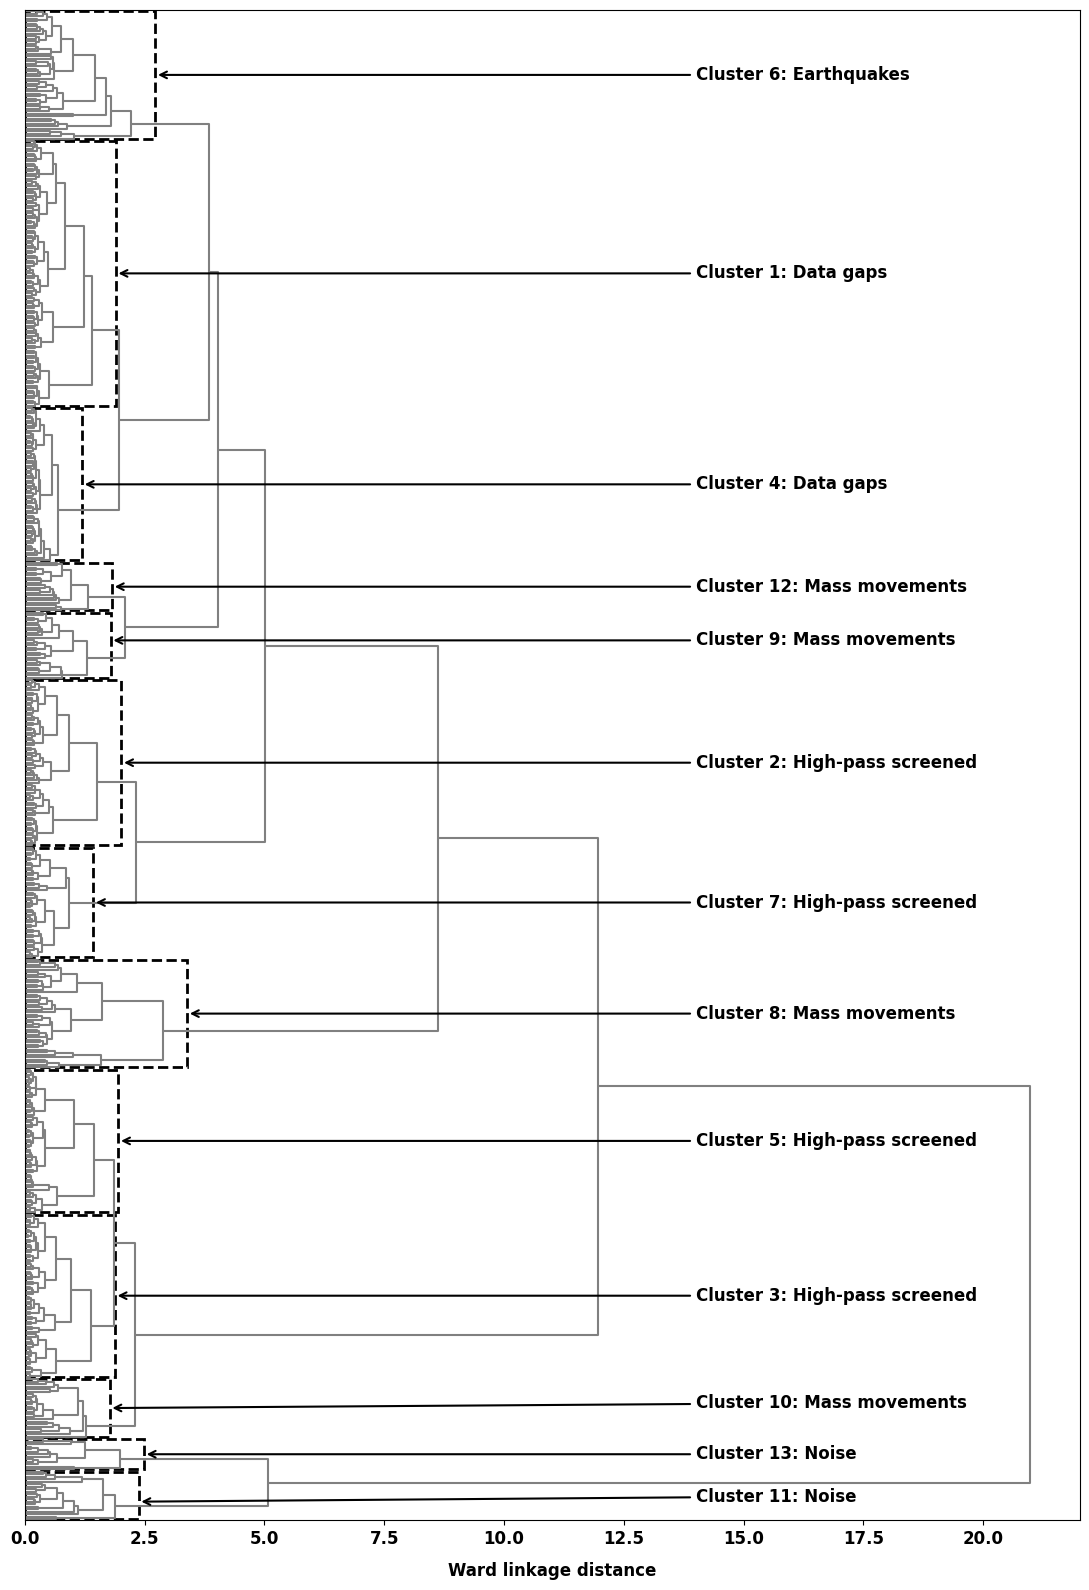

In [185]:
plt.figure(figsize=(11, 16))

ddata = dendrogram(
    Z, link_color_func=lambda k: "grey", orientation="right", no_labels=True
)

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()
x_positions = np.arange(len(leaf_order)) * 10 + 5

n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])


y_positions = np.arange(len(leaf_order)) * 10 + 5
gap = 5

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    y0 = y_positions[idx.min()] - 5 + gap
    y1 = y_positions[idx.max()] + 5 - gap
    width = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (0, y0),
        width,
        y1 - y0,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

    x_stop = 14.00

    if cid == 1:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 1: Data gaps",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 2:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 2: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 3:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 3: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 4:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 4: Data gaps",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 5:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 5: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 6:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 6: Earthquakes",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 7:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 7: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 8:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 8: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 9:
        y_center = (y0 + y1) / 2 + 20
        x_start = width

        ax.annotate(
            "Cluster 9: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 10:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 10: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 11:
        y_center = (y0 + y1) / 2 - 25
        x_start = width

        ax.annotate(
            "Cluster 11: Noise",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 12:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 12: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 13:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 13: Noise",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(12)

plt.xlabel("Ward linkage distance", fontweight="bold", fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()